In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import classification_report as score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
admissions = pd.read_csv('./Admission_Predict.csv')
admissions

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
395,396,324,110,3,3.5,3.5,9.04,1,0.82
396,397,325,107,3,3.0,3.5,9.11,1,0.84
397,398,330,116,4,5.0,4.5,9.45,1,0.91
398,399,312,103,3,3.5,4.0,8.78,0,0.67


In [3]:
#Data pre processing starts
admissions.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,200.500000,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.724350
std,115.614301,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.142609
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.340000
25%,100.750000,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.640000
50%,200.500000,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.730000
75%,300.250000,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,0.830000
max,400.000000,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,0.970000


In [4]:
admissions.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [5]:
admissions.dtypes

Serial No.             int64
GRE Score              int64
TOEFL Score            int64
University Rating      int64
SOP                  float64
LOR                  float64
CGPA                 float64
Research               int64
Chance of Admit      float64
dtype: object

In [6]:
admissions=admissions.drop(columns=['Serial No.'])

In [7]:
admissions.mean()

GRE Score            316.807500
TOEFL Score          107.410000
University Rating      3.087500
SOP                    3.400000
LOR                    3.452500
CGPA                   8.598925
Research               0.547500
Chance of Admit        0.724350
dtype: float64

In [8]:
admissions.median()

GRE Score            317.00
TOEFL Score          107.00
University Rating      3.00
SOP                    3.50
LOR                    3.50
CGPA                   8.61
Research               1.00
Chance of Admit        0.73
dtype: float64

In [9]:
admissions.mode()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,312,110.0,3.0,3.5,3.0,8.0,1.0,0.64
1,324,NaN,NaN,4.0,NaN,NaN,NaN,NaN


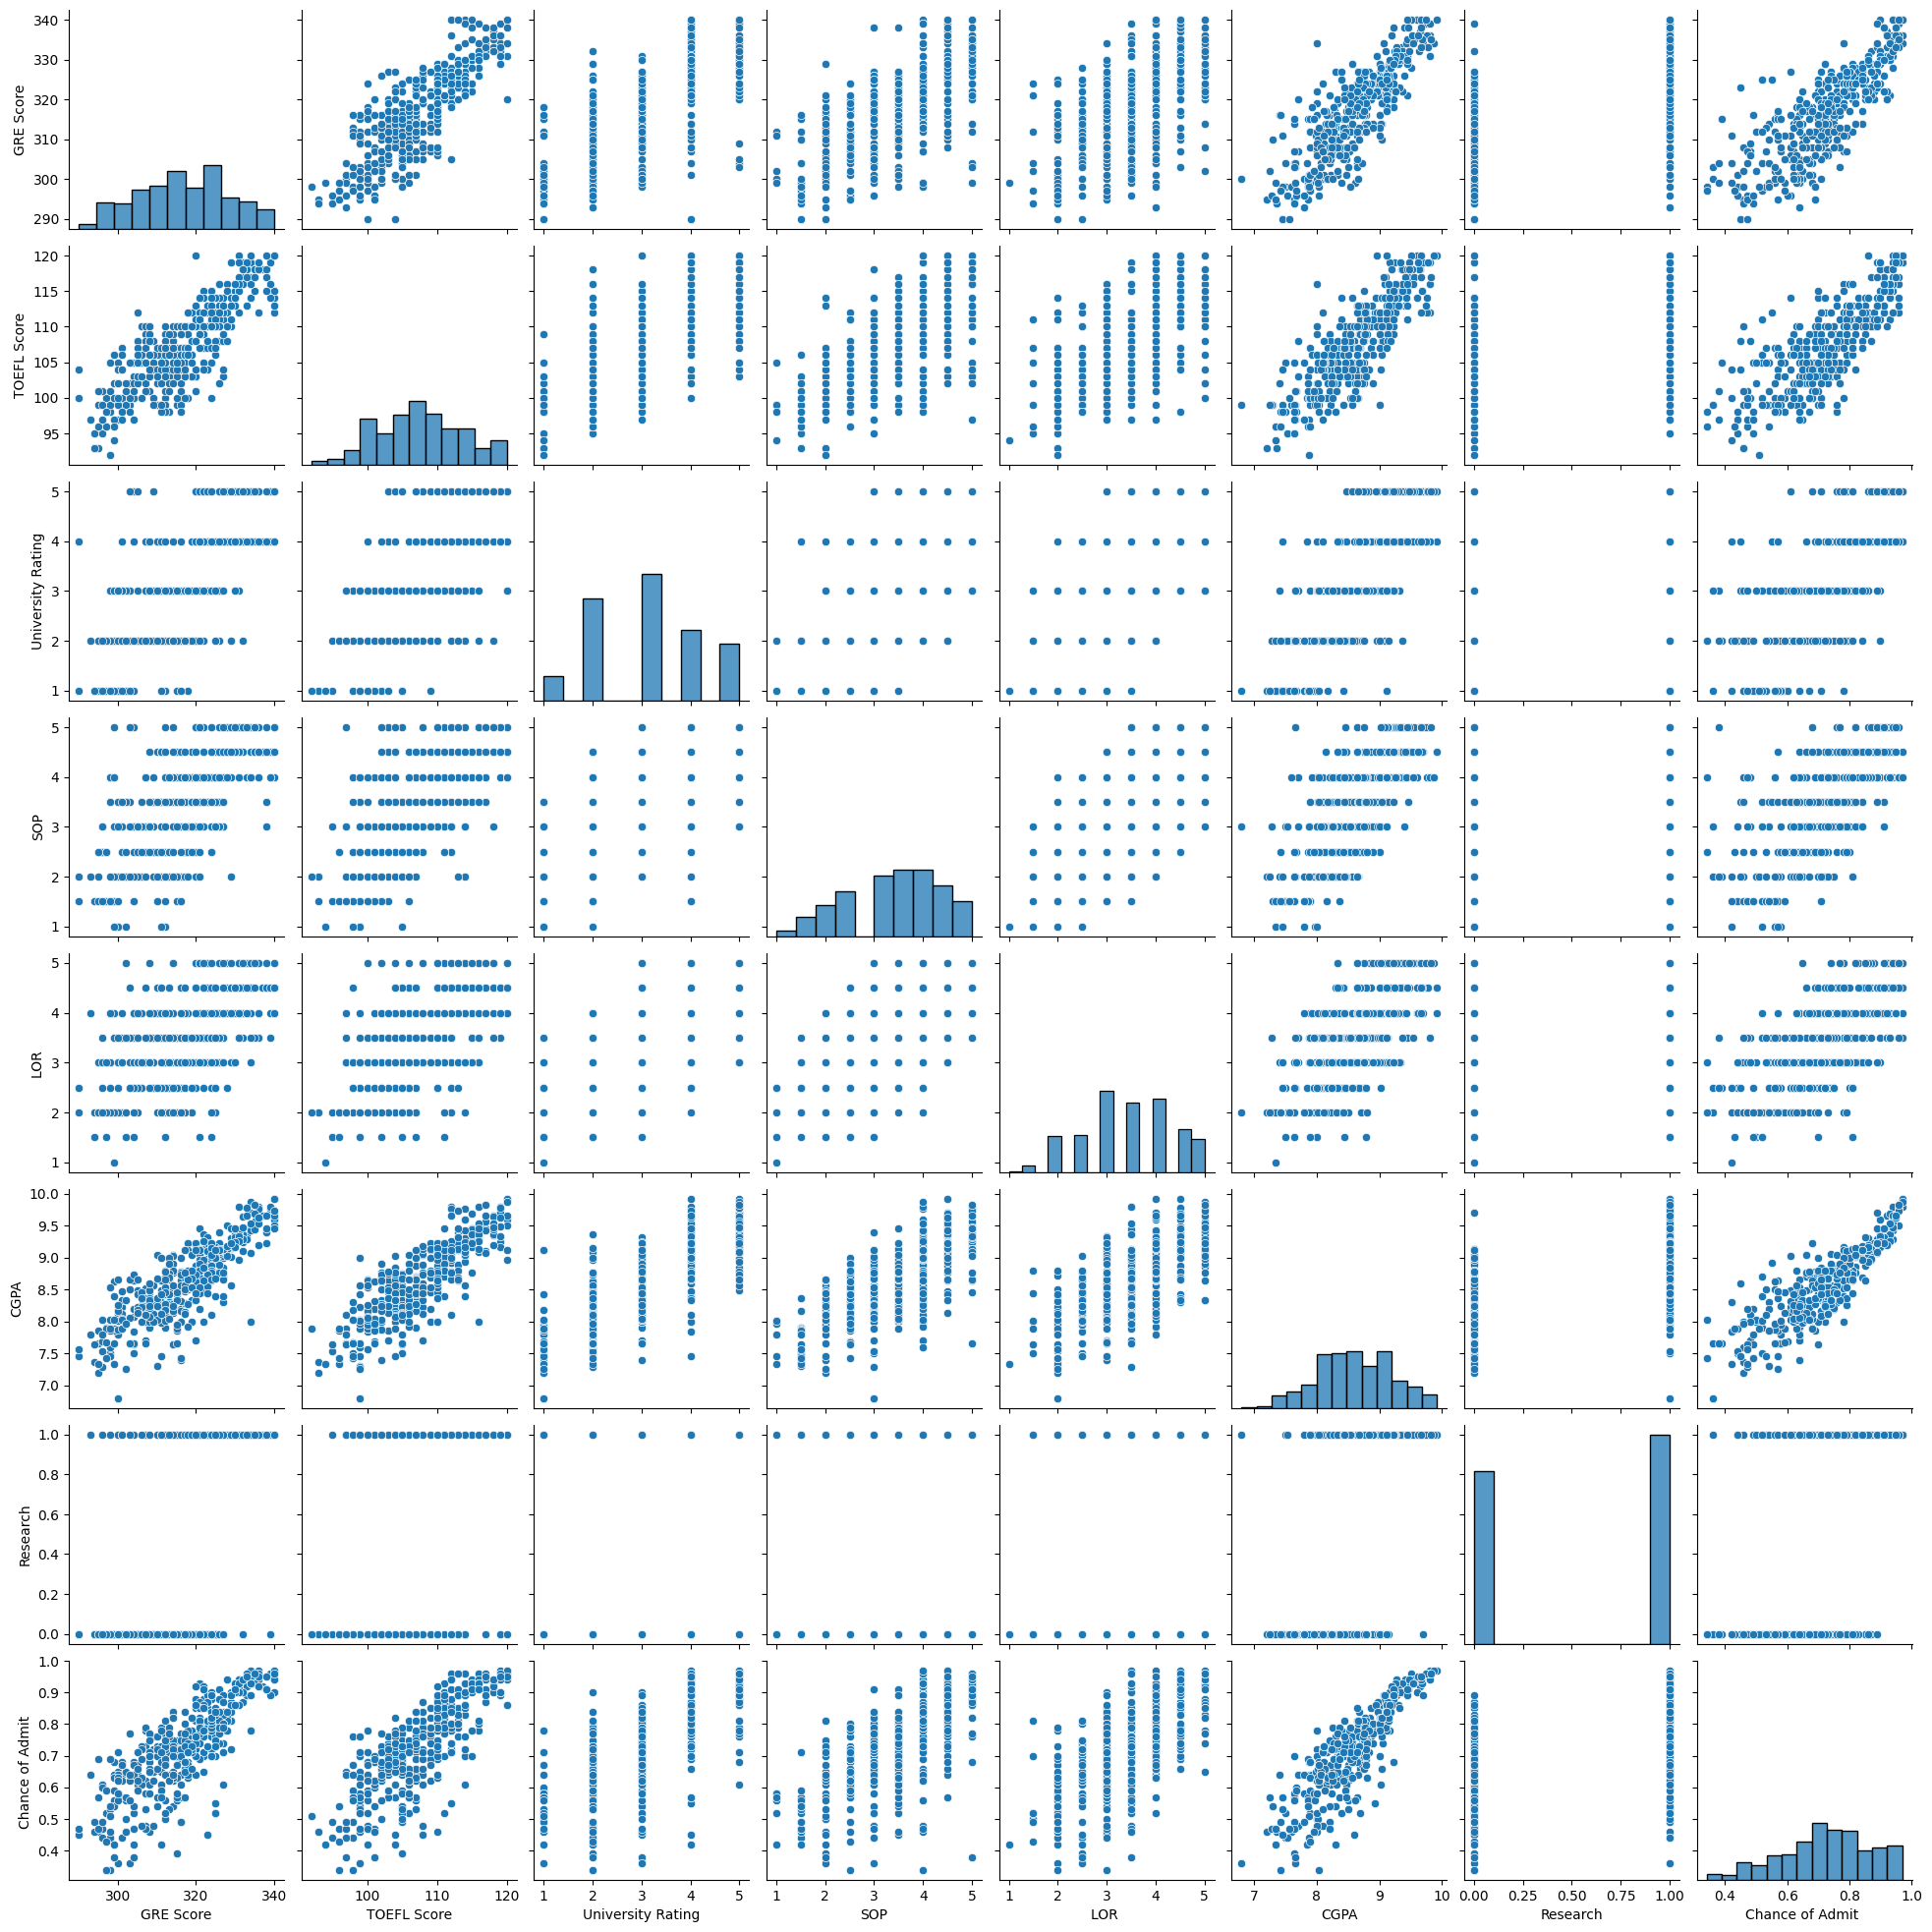

In [28]:
#Personal task - Draw any three graphs
sns.pairplot(admissions)

<AxesSubplot: >

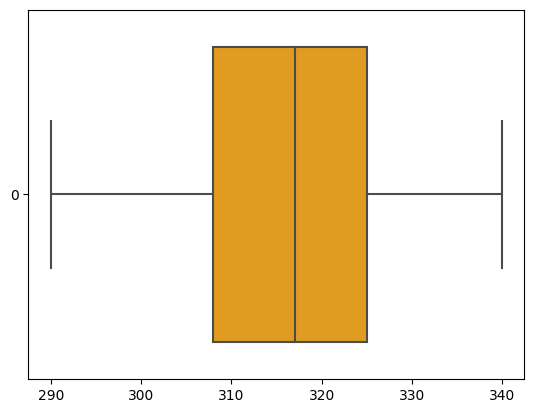

In [29]:
sns.boxplot(data=admissions['GRE Score'],orient="h",color='orange')

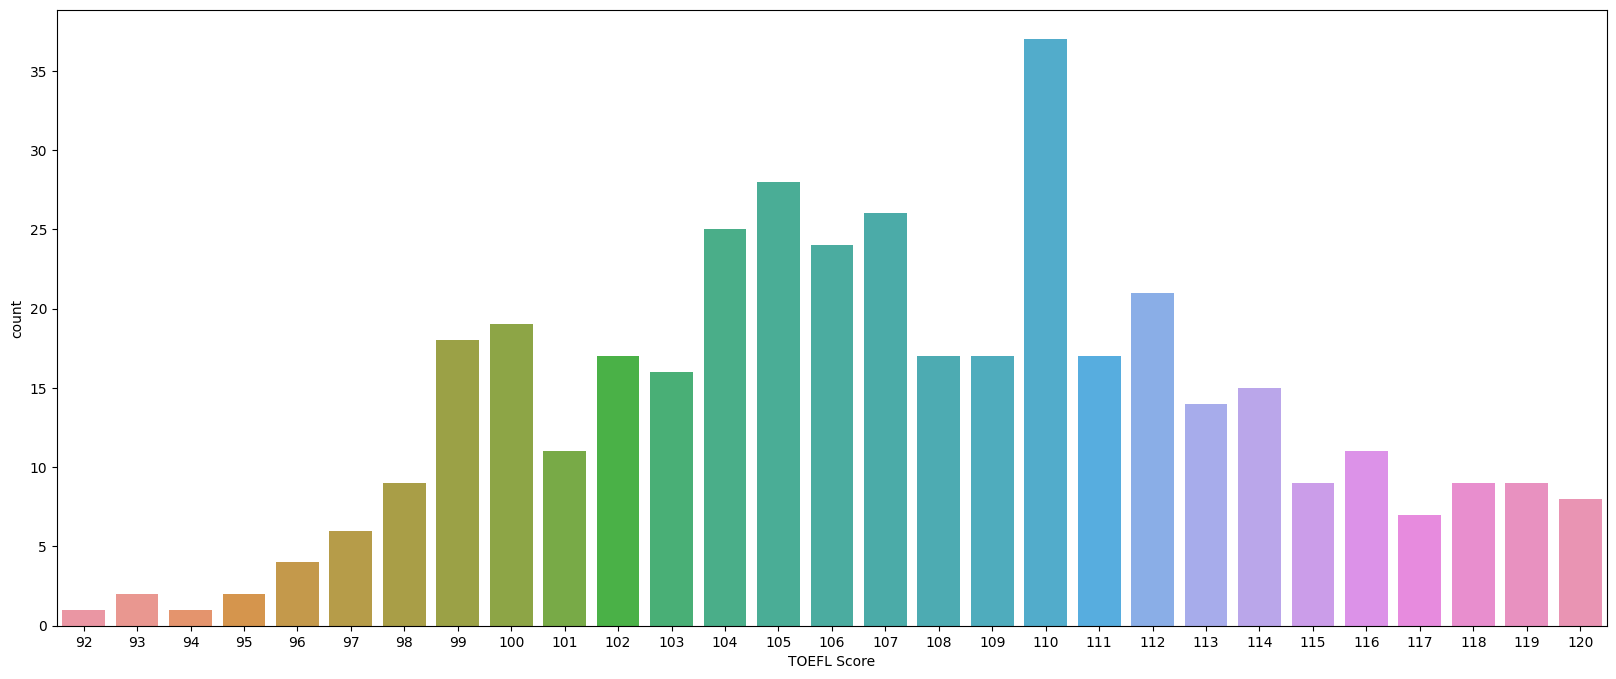

In [38]:
countplt=plt.figure(figsize=(20,8))
sns.countplot(data=admissions,x=admissions['TOEFL Score'])
plt.show()

In [10]:
x=admissions.drop(columns=['Chance of Admit '])
x

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1
3,322,110,3,3.5,2.5,8.67,1
4,314,103,2,2.0,3.0,8.21,0
...,...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04,1
396,325,107,3,3.0,3.5,9.11,1
397,330,116,4,5.0,4.5,9.45,1
398,312,103,3,3.5,4.0,8.78,0


In [11]:
y=(admissions['Chance of Admit ']>=0.8).astype(int)
y

0      1
1      0
2      0
3      1
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Chance of Admit , Length: 400, dtype: int64

In [12]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [13]:
chanceMe=DecisionTreeClassifier()
#Note : The default value taken in tree is Gini Index

In [14]:
chanceMe.fit(x_train,y_train)

DecisionTreeClassifier()

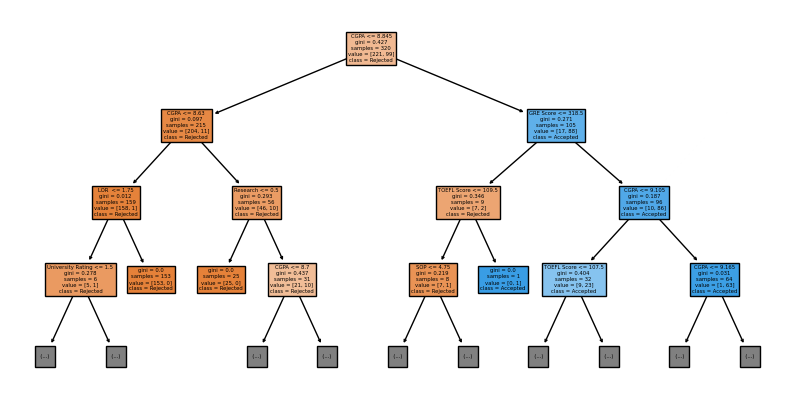

In [15]:
tree1 = plt.figure(figsize=(10,5))
plot_tree(chanceMe,max_depth=3,feature_names=['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA',
       'Research'],class_names=['Rejected','Accepted'],filled=True)
plt.show()

In [16]:
y_pred = chanceMe.predict(x_test)

In [17]:
accuracy_score(y_test,y_pred)

0.9125

In [18]:
confusion_matrix(y_test,y_pred)

array([[48,  3],
       [ 4, 25]])

In [19]:
print(score(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93        51
           1       0.89      0.86      0.88        29

    accuracy                           0.91        80
   macro avg       0.91      0.90      0.90        80
weighted avg       0.91      0.91      0.91        80



In [20]:
chanceMe2 = DecisionTreeClassifier(criterion="entropy")

In [21]:
chanceMe2.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy')

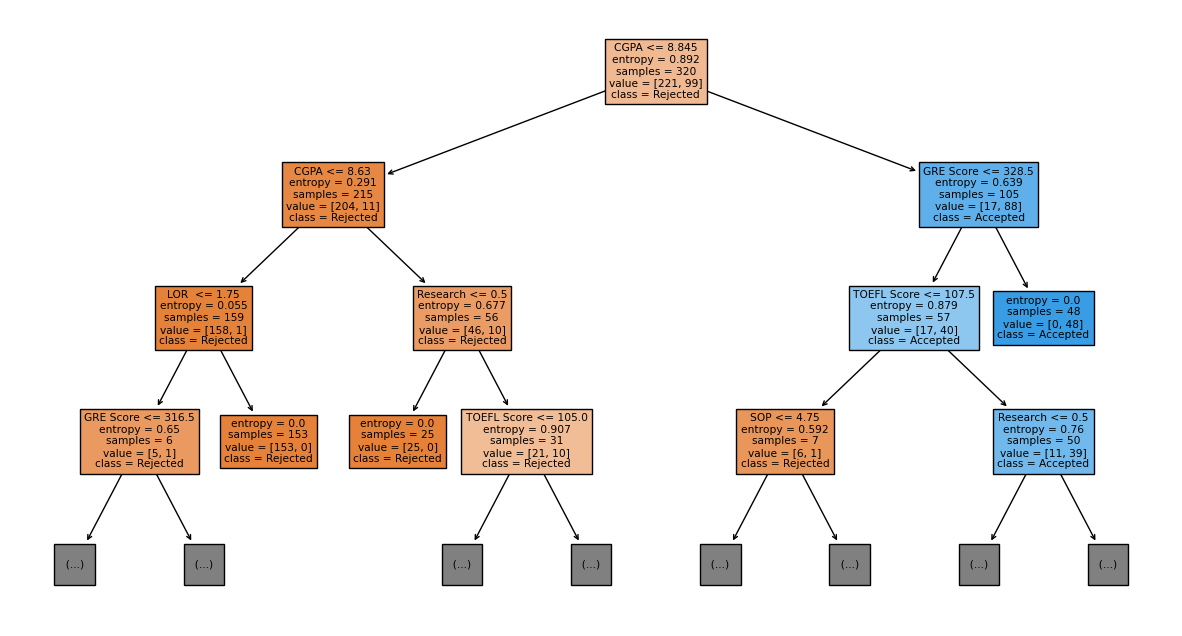

In [35]:
tree2=plt.figure(figsize=(15,8))
plot_tree(chanceMe2,max_depth=3,feature_names=['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA',
       'Research'],class_names=['Rejected','Accepted'],filled=True)
plt.show()

In [23]:
y_pred2 = chanceMe2.predict(x_test)

In [24]:
accuracy_score(y_test,y_pred2)

0.9375

In [25]:
confusion_matrix(y_test,y_pred2)

array([[49,  2],
       [ 3, 26]])

In [26]:
print(score(y_test,y_pred2))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95        51
           1       0.93      0.90      0.91        29

    accuracy                           0.94        80
   macro avg       0.94      0.93      0.93        80
weighted avg       0.94      0.94      0.94        80



In [27]:
print("Test your chances at your dream school")
GRE_Score = int(input("Enter your GRE score\n"))
TOEFL_Score = int(input("Enter your TOEFL score\n"))
University_Rating = int(input("Enter ranking of present university \n"))
SOP = float(input("Enter SOP quality score \n"))
LOR = float(input("Enter LOR quality score \n"))
CGPA = float(input("Enter CGPA (out of 10)\n"))
Research = int(input("Have you published research papers (1=yes,0=no)"))
if (chanceMe.predict([[GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research]])==1):
    print("Predictor 1: Congrats! You have a high chance!")
else:
    print("Predictor 1: Better luck next time")
if (chanceMe2.predict([[GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research]])==1):
    print("Predictor 2: Congrats! You have a high chance!")
else:
    print("Predictor 2: Better luck next time")

Test your chances at your dream school
Enter your GRE score
337
Enter your TOEFL score
118
Enter ranking of present university 
4
Enter SOP quality score 
4.5
Enter LOR quality score 
4.5
Enter CGPA (out of 10)
9.65
Have you published research papers (1=yes,0=no)1
Predictor 1: Congrats! You have a high chance!
Predictor 2: Congrats! You have a high chance!


/home/student/.local/lib/python3.8/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/student/.local/lib/python3.8/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
